In [ ]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
path = "/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 05/data"

In [2]:
#membaca file csv menggunakan pandas
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 05/data/Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
# Import library utama untuk pengolahan data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk machine learning (Decision Tree dan evaluasinya)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# 1. Melihat Informasi Awal Dataset

In [6]:
# Menampilkan informasi kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
# Menampilkan ringkasan statistik (mean, std, min, max, dll)
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
# Melihat distribusi jumlah data per kelas target (Species)
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [10]:
# 2. Mengecek dan Menghapus Data Kosong / Duplikat

In [11]:
# Mengecek apakah ada missing value
print("Jumlah missing value tiap kolom:\n", df.isnull().sum())

Jumlah missing value tiap kolom:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [12]:
# Mengecek apakah ada data duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [13]:
# Jika ada duplikat, hapus
df = df.drop_duplicates()

In [14]:
# 3. Encoding Kolom Target (Species) ke Bentuk Numerik

In [15]:
# Mengubah kolom Species menjadi kategori dan membuat kolom kode numerik
df['Species'] = df['Species'].astype('category')
df['Species_code'] = df['Species'].cat.codes

In [16]:
# Menampilkan contoh hasil encoding
df[['Species', 'Species_code']].head()

,Species,Species_code
0,Iris-setosa,0
1,Iris-setosa,0
2,Iris-setosa,0
3,Iris-setosa,0
4,Iris-setosa,0


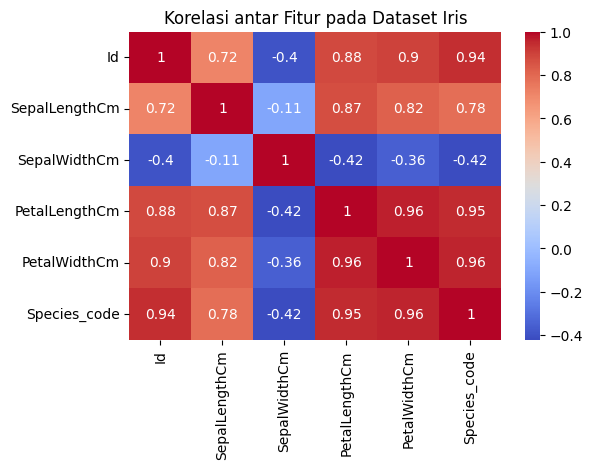

In [18]:
# 4. Analisis Korelasi antar Fitur
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Korelasi antar Fitur pada Dataset Iris")
plt.show()


In [20]:
# 5. Membagi Data menjadi Training dan Testing
# Menentukan fitur (X) dan target (y)
X = df.drop(columns=['Id', 'Species', 'Species_code'])
y = df['Species_code']

# Membagi dataset menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data training:", X_train.shape)
print("Jumlah data testing:", X_test.shape)

Jumlah data training: (120, 4)
Jumlah data testing: (30, 4)


In [22]:
# 6. Membuat Model Decision Tree
# Membuat model Decision Tree
model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

# Melatih model dengan data training
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [23]:
# 7. Evaluasi Model
# Prediksi data testing
y_pred = model.predict(X_test)

# Menampilkan hasil evaluasi
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi Model: 0.9333333333333333

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



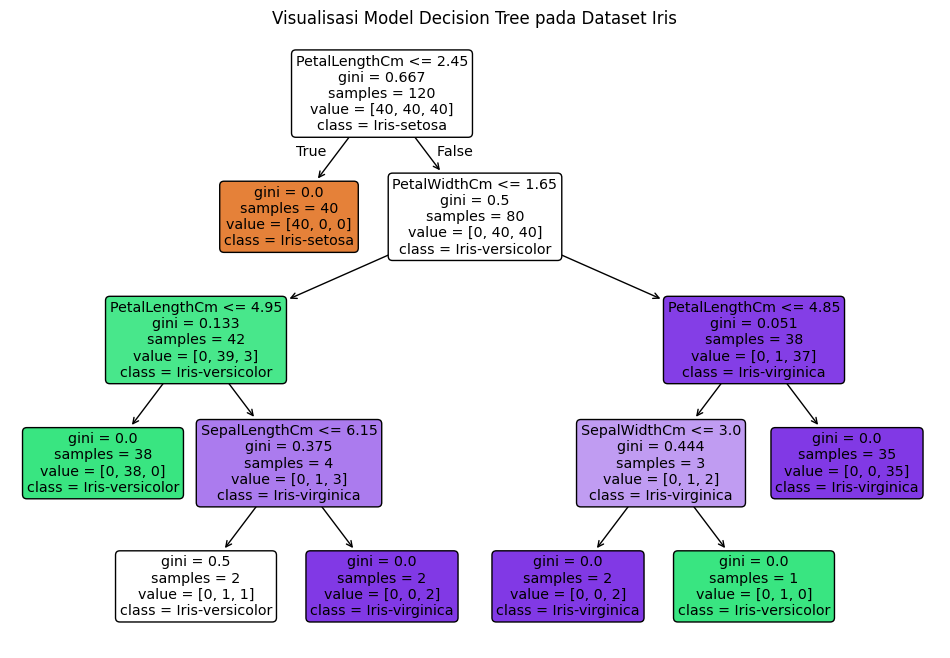

In [24]:
# 8. Visualisasi Pohon Keputusan
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=X.columns,
          class_names=df['Species'].cat.categories,
          filled=True, rounded=True)
plt.title("Visualisasi Model Decision Tree pada Dataset Iris")
plt.show()

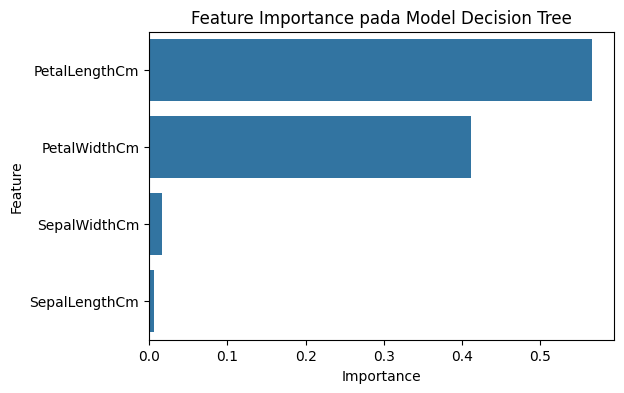

In [25]:
# 9. Menampilkan Feature Importance
# Membuat dataframe untuk melihat tingkat kepentingan fitur
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(6,4))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("Feature Importance pada Model Decision Tree")
plt.show()